<a href="https://colab.research.google.com/github/tpk-cdu-451/HIT140_FIFA_Analysis/blob/main/Card_recieved_per_fouls_Committed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Analytic question**
Does the rate of cards (Yellow & Red) received per foul significantly higher among losing teams compared to winning teams during the FIFA World Cup 2026?

#How dataset is fetched from The Stats Don't Lie:

In [39]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

sheet_id = "2PACX-1vSWZFlaUHTBK09v4I1Kv7ZQ0ophhlpsCr7VPFW5dkbdG0Zpl8mRkXrTZezZMr1Ia9V9cpwmq7BKPQ03"
gid = "995472238"

###URL from inspect_network
csv_url = (
    f"https://docs.google.com/spreadsheets/d/e/{sheet_id}/"
    f"pub?gid={gid}&single=true&output=csv"
)

raw = pd.read_csv(csv_url, header=[0, 1])

print(raw.shape)
display(raw.head(10))

(119, 28)


,GROUP STAGE,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,...,Unnamed: 18_level_0,Unnamed: 19_level_0,Unnamed: 20_level_0,Unnamed: 21_level_0,Unnamed: 22_level_0,Unnamed: 23_level_0,Unnamed: 24_level_0,Unnamed: 25_level_0,Unnamed: 26_level_0,Unnamed: 27_level_0
,Unnamed: 0_level_1,Unnamed: 1_level_1,Unnamed: 2_level_1,Unnamed: 3_level_1,Unnamed: 4_level_1,GOALS,Unnamed: 6_level_1,Unnamed: 7_level_1,Unnamed: 8_level_1,CARDS,...,Unnamed: 18_level_1,Unnamed: 19_level_1,xG,Unnamed: 21_level_1,SHOTS,Unnamed: 23_level_1,SHOTS ON\nTARGET,Unnamed: 25_level_1,FOULS,Unnamed: 27_level_1
0,Date,Team 1,Result,NaN,Team 2,1H,NaN,2H,NaN,YEL,...,NaN,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11/06/2026,Mexico,2,0,South Africa,1,0.0,1,0.0,1,...,1.0,4,1.46,0.07,16,3.0,4,2.0,12,11.0
2,12/06/2026,South Korea,2,1,Czech Republic,0,0.0,2,1.0,1,...,5.0,9,2.30,0.83,15,7.0,6,4.0,9,16.0
3,12/06/2026,Canada,1,1,Bosnia & Herzegovina,0,1.0,1,0.0,2,...,4.0,13,1.25,0.98,13,8.0,4,3.0,10,20.0
4,13/06/2026,USA,4,1,Paraguay,3,0.0,1,1.0,1,...,1.0,4,1.42,0.54,16,9.0,6,1.0,13,17.0
5,13/06/2026,Qatar,1,1,Switzerland,0,1.0,1,0.0,2,...,10.0,13,0.60,3.20,6,26.0,3,7.0,12,11.0
6,13/06/2026,Brazil,1,1,Morocco,1,1.0,0,0.0,2,...,2.0,8,1.26,1.37,12,14.0,5,3.0,16,14.0
7,14/06/2026,Haiti,0,1,Scotland,0,1.0,0,0.0,1,...,3.0,7,1.05,1.05,15,9.0,2,2.0,23,21.0
8,14/06/2026,Australia,2,0,Turkey,1,0.0,1,0.0,0,...,8.0,13,1.18,1.36,9,30.0,4,8.0,12,4.0


In [40]:
for i in range(10):
    print(
        f"{i:2} | "
        f"Row 0 = {raw.iloc[0, i]!r:25} | "
        f"Row 1 = {raw.iloc[1, i]!r}"
    )

 0 | Row 0 = 'Date'                    | Row 1 = '11/06/2026'
 1 | Row 0 = 'Team 1'                  | Row 1 = 'Mexico'
 2 | Row 0 = 'Result'                  | Row 1 = '2'
 3 | Row 0 = nan                       | Row 1 = '0'
 4 | Row 0 = 'Team 2'                  | Row 1 = 'South Africa'
 5 | Row 0 = '1H'                      | Row 1 = '1'
 6 | Row 0 = np.float64(nan)           | Row 1 = np.float64(0.0)
 7 | Row 0 = '2H'                      | Row 1 = '1'
 8 | Row 0 = np.float64(nan)           | Row 1 = np.float64(0.0)
 9 | Row 0 = 'YEL'                     | Row 1 = '1'


In [41]:
data = raw.iloc[2:].copy()

data.columns = [f"col_{i}" for i in range(28)]

# creating and assigning columns name
data = data.rename(columns={
    "col_0": "date",
    "col_1": "team1",
    "col_2": "team1_goals",
    "col_3": "team2_goals",
    "col_4": "team2",

    "col_5": "team1_1h_goals",
    "col_6": "team2_1h_goals",
    "col_7": "team1_2h_goals",
    "col_8": "team2_2h_goals",

    "col_21": "team1_xg",
    "col_22": "team2_xg",

    "col_23": "team1_shots",
    "col_24": "team2_shots",

    "col_25": "team1_shots_on_target",
    "col_26": "team2_shots_on_target",

    "col_27": "team1_fouls",
})


In [42]:
#Checked for data
for i in range(10):
    print(
        f"{i:2} | "
        f"Row 1 = {raw.iloc[1, i]!r} | "
        f"Row 2 = {raw.iloc[2, i]!r}"
    )


 0 | Row 1 = '11/06/2026' | Row 2 = '12/06/2026'
 1 | Row 1 = 'Mexico' | Row 2 = 'South Korea'
 2 | Row 1 = '2' | Row 2 = '2'
 3 | Row 1 = '0' | Row 2 = '1'
 4 | Row 1 = 'South Africa' | Row 2 = 'Czech Republic'
 5 | Row 1 = '1' | Row 2 = '0'
 6 | Row 1 = np.float64(0.0) | Row 2 = np.float64(0.0)
 7 | Row 1 = '1' | Row 2 = '2'
 8 | Row 1 = np.float64(0.0) | Row 2 = np.float64(1.0)
 9 | Row 1 = '1' | Row 2 = '1'


In [43]:
# Raw dataframe

print("Raw shape:", raw.shape)

data = raw.iloc[1:].copy().reset_index(drop=True)

print("After removing headers:", data.shape)

# 3. Column names

columns = [
    "date",
    "team_1",
    "team_1_goals",
    "team_2_goals",
    "team_2",

    "team_1_1h_goals",
    "team_2_1h_goals",
    "team_1_2h_goals",
    "team_2_2h_goals",

    "team_1_yellow",
    "team_2_yellow",
    "team_1_red",
    "team_2_red",

    "team_1_1h_corners",
    "team_2_1h_corners",
    "team_1_2h_corners",
    "team_2_2h_corners",
    "team_1_match_corners",
    "team_2_match_corners",
    "team_1_total_corners",

    "team_1_xg",
    "team_2_xg",

    "team_1_shots",
    "team_2_shots",

    "team_1_shots_on_target",
    "team_2_shots_on_target",

    "team_1_fouls",
    "team_2_fouls",
]

# len of column and data shape check
assert len(columns) == 28
assert data.shape[1] == 28

data.columns = columns

# Date Coversion

data["date"] = pd.to_datetime(
    data["date"],
    dayfirst=True,
    errors="coerce"
)

# Numeric columns Conversion

numeric_columns = [
    col for col in columns
    if col not in ["date", "team_1", "team_2"]
]

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Empty rows removed

data = data.dropna(
    subset=["date", "team_1", "team_2"]
).reset_index(drop=True)


Raw shape: (119, 28)
After removing headers: (118, 28)


In [44]:
from google.colab import files

# Save data as CSV
data.to_csv("world_cup_2026_cleaned.csv", index=False)

# Download to your computer
files.download("world_cup_2026_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# DATA WRANGLING

In [45]:
# Load dataset
print("Initial dataset shape:", data.shape)
# Display column names
data.head()

#to proceed with downloaded data
#df = pd.read_csv("/content/world_cup_2026_fixtures_results_stats.csv")
#print("Initial dataset shape:", df.shape)
# Display column names
#df.head()

Initial dataset shape: (103, 28)


,date,team_1,team_1_goals,team_2_goals,team_2,team_1_1h_goals,team_2_1h_goals,team_1_2h_goals,team_2_2h_goals,team_1_yellow,...,team_2_match_corners,team_1_total_corners,team_1_xg,team_2_xg,team_1_shots,team_2_shots,team_1_shots_on_target,team_2_shots_on_target,team_1_fouls,team_2_fouls
0,2026-06-11,Mexico,2.0,0.0,South Africa,1.0,0.0,1.0,0.0,1.0,...,1.0,4.0,1.46,0.07,16.0,3.0,4.0,2.0,12.0,11.0
1,2026-06-12,South Korea,2.0,1.0,Czech Republic,0.0,0.0,2.0,1.0,1.0,...,5.0,9.0,2.30,0.83,15.0,7.0,6.0,4.0,9.0,16.0
2,2026-06-12,Canada,1.0,1.0,Bosnia & Herzegovina,0.0,1.0,1.0,0.0,2.0,...,4.0,13.0,1.25,0.98,13.0,8.0,4.0,3.0,10.0,20.0
3,2026-06-13,USA,4.0,1.0,Paraguay,3.0,0.0,1.0,1.0,1.0,...,1.0,4.0,1.42,0.54,16.0,9.0,6.0,1.0,13.0,17.0
4,2026-06-13,Qatar,1.0,1.0,Switzerland,0.0,1.0,1.0,0.0,2.0,...,10.0,13.0,0.60,3.20,6.0,26.0,3.0,7.0,12.0,11.0


In [46]:
print("---DATASET INFORMATION--")

print(data.info())

---DATASET INFORMATION--
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    103 non-null    datetime64[ns]
 1   team_1                  103 non-null    object        
 2   team_1_goals            102 non-null    float64       
 3   team_2_goals            100 non-null    float64       
 4   team_2                  103 non-null    object        
 5   team_1_1h_goals         103 non-null    float64       
 6   team_2_1h_goals         103 non-null    float64       
 7   team_1_2h_goals         103 non-null    float64       
 8   team_2_2h_goals         103 non-null    float64       
 9   team_1_yellow           103 non-null    float64       
 10  team_2_yellow           103 non-null    float64       
 11  team_1_red              103 non-null    float64       
 12  team_2_red              1

In [47]:
# Check missing values
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
date                      0
team_1                    0
team_1_goals              1
team_2_goals              3
team_2                    0
team_1_1h_goals           0
team_2_1h_goals           0
team_1_2h_goals           0
team_2_2h_goals           0
team_1_yellow             0
team_2_yellow             0
team_1_red                0
team_2_red                0
team_1_1h_corners         0
team_2_1h_corners         0
team_1_2h_corners         0
team_2_2h_corners         0
team_1_match_corners      0
team_2_match_corners      0
team_1_total_corners      0
team_1_xg                 0
team_2_xg                 0
team_1_shots              0
team_2_shots              0
team_1_shots_on_target    0
team_2_shots_on_target    0
team_1_fouls              0
team_2_fouls              0
dtype: int64


DATA CLEANING

In [48]:
#Removing/dropping the null values
df_2 = data.dropna(
    subset=["team_1_goals", "team_2_goals"]
).copy()

print("\nBefore removing missing scores:",
      len(data))

print("After removing missing scores:",
      len(df_2))

print("Total number of Matches removed:",
      len(data) - len(df_2))


Before removing missing scores: 103
After removing missing scores: 99
Total number of Matches removed: 4


CREATE TEAM-LEVEL DATA & FEATURE ENGINEERING

In [49]:
# converting two team-level observations for clear understanding and selected necessary columns
team_data = []

for _, row in df_2.iterrows():

    # Team 1
    team_data.append({
        "date": row["date"],
        "team": row["team_1"],
        "goals_for": row["team_1_goals"],
        "goals_against": row["team_2_goals"],
        "yellow_cards": row["team_1_yellow"],
        "red_cards": row["team_1_red"],
        "fouls": row["team_1_fouls"]
    })

    # Team 2
    team_data.append({
        "date": row["date"],
        "team": row["team_2"],
        "goals_for": row["team_2_goals"],
        "goals_against": row["team_1_goals"],
        "yellow_cards": row["team_2_yellow"],
        "red_cards": row["team_2_red"],
        "fouls": row["team_2_fouls"]
    })

team_df = pd.DataFrame(team_data)

print("\nTeam-level dataset:")
team_df.head()


Team-level dataset:


,date,team,goals_for,goals_against,yellow_cards,red_cards,fouls
0,2026-06-11,Mexico,2.0,0.0,1.0,1.0,12.0
1,2026-06-11,South Africa,0.0,2.0,2.0,2.0,11.0
2,2026-06-12,South Korea,2.0,1.0,1.0,0.0,9.0
3,2026-06-12,Czech Republic,1.0,2.0,0.0,0.0,16.0
4,2026-06-12,Canada,1.0,1.0,2.0,0.0,10.0


DETERMINE WIN / LOSS / DRAW

In [50]:

### Determining Win/Loss/Draw of match by checking goals obtained
def determine_result(row):

    if row["goals_for"] > row["goals_against"]:
        return "Win"

    elif row["goals_for"] < row["goals_against"]:
        return "Loss"

    else:
        return "Draw"


team_df["result"] = team_df.apply(
    determine_result,
    axis=1
)

print("\nNumber of observations :")
print(team_df["result"].value_counts())


Number of observations :
result
Win     79
Loss    79
Draw    40
Name: count, dtype: int64


In [51]:
# Since the comparison is between winning teams with losing teams, so dropping Draw Matches

result_df = team_df[
    team_df["result"].isin(["Win", "Loss"])
].copy()

print("\nComplete analysis dataset:")
print(result_df["result"].value_counts())


Complete analysis dataset:
result
Win     79
Loss    79
Name: count, dtype: int64


 CALCULATE TOTAL CARDS

In [52]:
# Total cards = Addition of Yellow cards and Red cards

result_df["total_cards"] = (
    result_df["yellow_cards"] +
    result_df["red_cards"]
)

CALCULATE CARD-PER-FOUL RATE


In [53]:
# To calculate the cards received fouls comitted
result_df["card_per_foul"] = (
    result_df["total_cards"] /
    result_df["fouls"]
)

# Display values of card per foul
print("\n --- Calculated values: ---")
print(
    result_df[
        [
            "team",
            "result",
            "fouls",
            "yellow_cards",
            "red_cards",
            "total_cards",
            "card_per_foul"
        ]
    ].head()
)
result_df.shape



 --- Calculated values: ---
             team result  fouls  yellow_cards  red_cards  total_cards  \
0          Mexico    Win   12.0           1.0        1.0          2.0   
1    South Africa   Loss   11.0           2.0        2.0          4.0   
2     South Korea    Win    9.0           1.0        0.0          1.0   
3  Czech Republic   Loss   16.0           0.0        0.0          0.0   
6             USA    Win   13.0           1.0        0.0          1.0   

   card_per_foul  
0       0.166667  
1       0.363636  
2       0.111111  
3       0.000000  
6       0.076923  


(158, 10)

#OUTLIERS CHECK FOR CARD_PER_FOUL

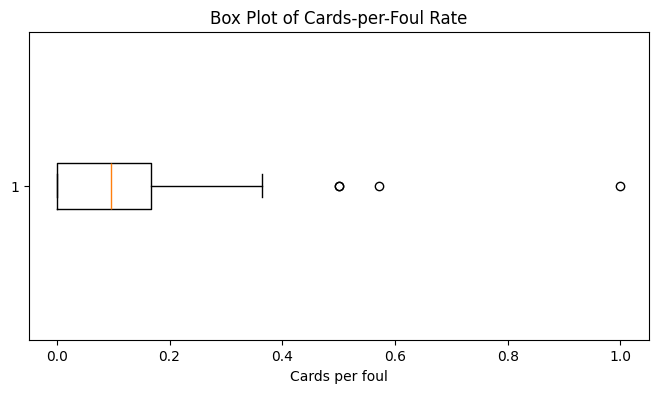

In [54]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    result_df["card_per_foul"],
    vert=False
)

plt.xlabel("Cards per foul")

plt.title(
    "Box Plot of Cards-per-Foul Rate"
)

plt.show()

/tmp/ipykernel_952/913186959.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


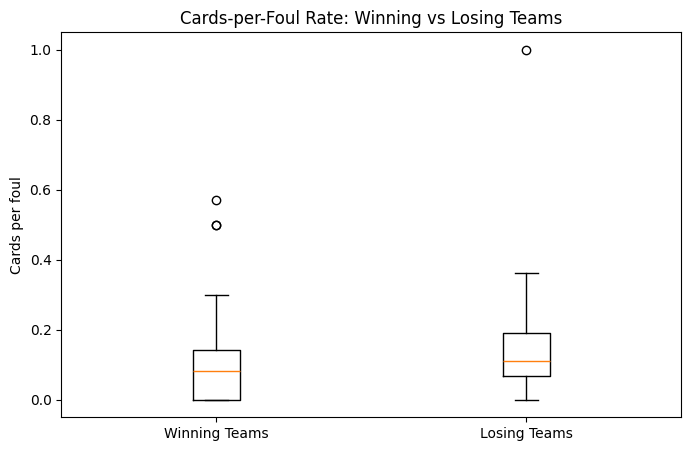

In [55]:
#Checking for particular teams
winning_data = result_df[
    result_df["result"] == "Win"
]["card_per_foul"]

losing_data = result_df[
    result_df["result"] == "Loss"
]["card_per_foul"]


plt.figure(figsize=(8, 5))

plt.boxplot(
    [winning_data, losing_data],
    labels=["Winning Teams", "Losing Teams"]
)

plt.ylabel("Cards per foul")

plt.title(
    "Cards-per-Foul Rate: Winning vs Losing Teams"
)

plt.show()

In [56]:
#IQR outlier analysis of dataset
Q1 = result_df["card_per_foul"].quantile(0.25)

Q3 = result_df["card_per_foul"].quantile(0.75)

IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR


print("--- IQR OUTLIER ANALYSIS ---")

print("Q1:", Q1)

print("Q3:", Q3)

print("IQR:", IQR)

print("Lower bound:", lower_bound)

print("Upper bound:", upper_bound)


# Show which data are identified as outliers

outliers = result_df[
    (result_df["card_per_foul"] < lower_bound) |
    (result_df["card_per_foul"] > upper_bound)
].copy()


print("\nTotal number of outliers:",
      len(outliers))


print("\nOutlier observations:")

print(
    outliers[
        [
            "team",
            "result",
            "fouls",
            "yellow_cards",
            "red_cards",
            "total_cards",
            "card_per_foul"
        ]
    ]
)

--- IQR OUTLIER ANALYSIS ---
Q1: 0.0
Q3: 0.16666666666666666
IQR: 0.16666666666666666
Lower bound: -0.25
Upper bound: 0.41666666666666663

Total number of outliers: 4

Outlier observations:
             team result  fouls  yellow_cards  red_cards  total_cards  \
73   Saudi Arabia   Loss    2.0           2.0        0.0          2.0   
138    D.R. Congo    Win    6.0           3.0        0.0          3.0   
146        Brazil    Win    4.0           2.0        0.0          2.0   
177       England    Win    7.0           3.0        1.0          4.0   

     card_per_foul  
73        1.000000  
138       0.500000  
146       0.500000  
177       0.571429  


Total 4 outliers were identified but not dropping because it is not invalid data, the value of card_per_foul was high with valid fouls and total card

#DEFINE POPULATION AND SAMPLE


In [57]:
population = result_df.copy()

print("--- POPULATION ---")
print(
    "Population size:",
    len(population)
)

print(
    population["result"].value_counts()
)

--- POPULATION ---
Population size: 158
result
Win     79
Loss    79
Name: count, dtype: int64


#STRATIFIED RANDOM SAMPLING







In [58]:
# Step1: Dividing population into 2 strata:
           #1. Winning teams
           #2. Losing teams

# Step2: Randomly select the same amount of data from
         #each stratum.

sample_fraction = 0.80
#Winning team sample
winning_population = population[
    population["result"] == "Win"
]
winning_sample = winning_population.sample(
    frac=sample_fraction,
    random_state=42
)

#Losing team sample
losing_population = population[
    population["result"] == "Loss"
]

losing_sample = losing_population.sample(
    frac=sample_fraction,
    random_state=42
)

#Combining both strata
sample_df = pd.concat(
    [
        winning_sample,
        losing_sample
    ]
)

# Shuffling sample
sample_df = sample_df.sample(
    frac=1,
    random_state=42
).reset_index(
    drop=True
)

print("--- SAMPLE ---")

print(
    "Sample size:",
    len(sample_df)
)

print(
    "\nSample distribution:"
)

print(
    sample_df["result"].value_counts()
)

--- SAMPLE ---
Sample size: 126

Sample distribution:
result
Loss    63
Win     63
Name: count, dtype: int64


**POPULATION**: All eligible winning and losing team performances in FIFA World Cup 2026 matches.

**SAMPLE**: Eligible team-level observations from the provided dataset after removing matches with missing scores and drawn matches.


#CREATE WINNING AND LOSING GROUPS FOR SAMPLE DATASET


In [59]:
winners = sample_df[
    sample_df["result"] == "Win"
]["card_per_foul"]


losers = sample_df[
    sample_df["result"] == "Loss"
]["card_per_foul"]


print(
    "\nWinning sample size:",
    len(winners)
)

print(
    "Losing sample size:",
    len(losers)
)


Winning sample size: 63
Losing sample size: 63


#DESCRIPTIVE STATISTICS


In [60]:
print("------ DESCRIPTIVE STATISTICS -----")

print("\nWinning Teams:")
print(winners.describe())

print("\nLosing Teams:")
print(losers.describe())


------ DESCRIPTIVE STATISTICS -----

Winning Teams:
count    63.000000
mean      0.109200
std       0.126017
min       0.000000
25%       0.000000
50%       0.083333
75%       0.160256
max       0.571429
Name: card_per_foul, dtype: float64

Losing Teams:
count    63.000000
mean      0.145449
std       0.144153
min       0.000000
25%       0.074176
50%       0.125000
75%       0.181818
max       1.000000
Name: card_per_foul, dtype: float64


In [61]:
#Comparing means
winner_mean = winners.mean()
loser_mean = losers.mean()

mean_difference = loser_mean - winner_mean

print("----- MEAN COMPARISON ------")

print("Mean of Winning team:", winner_mean)
print("Mean of Losing team:", loser_mean)
print("Difference (Losing - Winning):", mean_difference)


----- MEAN COMPARISON ------
Mean of Winning team: 0.10920016120517374
Mean of Losing team: 0.14544873300757574
Difference (Losing - Winning): 0.036248571802402


#95% CONFIDENCE INTERVAL


In [62]:
# Calculating confidence interval between the two group means.

winner_v = winners.var(ddof=1)
loser_v = losers.var(ddof=1)

winner_n = len(winners)
loser_n = len(losers)

# Standard error of the difference
std_error = np.sqrt(
    (loser_v / loser_n) +
    (winner_v / winner_n)
)

# Welch degrees of freedom
degree_of_freedom = (
    (
        (loser_v / loser_n) +
        (winner_v / winner_n)
    ) ** 2
    /
    (
        ((loser_v / loser_n) ** 2 / (loser_n - 1))
        +
        ((winner_v / winner_n) ** 2 / (winner_n - 1))
    )
)

# 95% important value
imp_value = stats.t.ppf(
    0.975,
    degree_of_freedom
)

# Margin of error
margin_of_error = (
    imp_value *
    std_error
)

# Confidence interval
ci_lower = (
    mean_difference -
    margin_of_error
)

ci_upper = (
    mean_difference +
    margin_of_error
)

print("-------- 95% CONFIDENCE INTERVAL -----------")

print("Mean difference:", mean_difference)
print("Lower limit:", ci_lower)
print("Upper limit:", ci_upper)
print("Degrees of freedom:", degree_of_freedom)

-------- 95% CONFIDENCE INTERVAL -----------
Mean difference: 0.036248571802402
Lower limit: -0.011505603806814167
Upper limit: 0.08400274741161817
Degrees of freedom: 121.82392928765113


The range for the difference of losing and winning teams is about -0.0115 to 0.0840. Since, 0 is included in the range, CI shows true difference could be zero




#TWO-SAMPLE T-TEST


--------- TWO-SAMPLE T-TEST -----------
t-statistic: 1.5026687453909457
Two-tailed p-value: 0.13551229571147597
One-tailed p-value: 0.06775614785573798


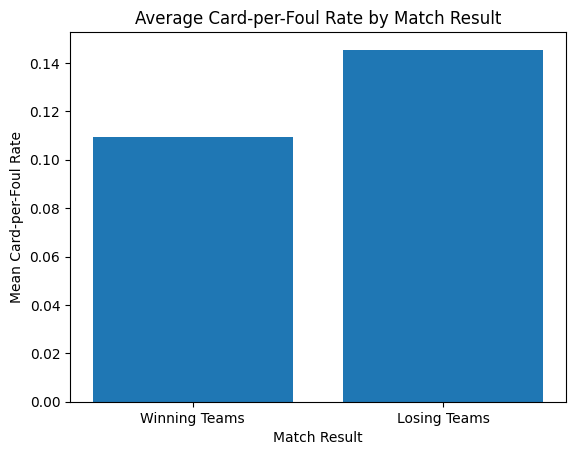

In [63]:
#Two-sample t-test
# H0: Losing teams <= higher mean rate.
# H1: Losing teams > higher mean rate.

t_statistic, p_value_two_tailed = stats.ttest_ind(
    losers,
    winners,
    equal_var=False
)

# Converted two-tailed p-value to one-tailed p-value due to Losing teams > Winning teams

if t_statistic > 0:
    p_value_one_tailed = p_value_two_tailed / 2
else:
    p_value_one_tailed = 1 - (p_value_two_tailed / 2)

print("--------- TWO-SAMPLE T-TEST -----------")

print("t-statistic:", t_statistic)
print("Two-tailed p-value:", p_value_two_tailed)
print("One-tailed p-value:", p_value_one_tailed)

##bargraph plotting
means = [
    winner_mean,
    loser_mean
]

groups = [
    "Winning Teams",
    "Losing Teams"
]

plt.bar(groups, means)

plt.xlabel("Match Result")
plt.ylabel("Mean Card-per-Foul Rate")
plt.title("Average Card-per-Foul Rate by Match Result")

plt.show()

In [64]:
print("Mean of Winning Team:", winner_mean)
print("Mean of Losing Team:", loser_mean)

print("Sample size(Winner):", winner_n)
print("Sample size(Loser):", loser_n)

print("Mean difference (Loser - Winner):", mean_difference)
print("t-statistic:", t_statistic)
print("p-value:", p_value_one_tailed)

Mean of Winning Team: 0.10920016120517374
Mean of Losing Team: 0.14544873300757574
Sample size(Winner): 63
Sample size(Loser): 63
Mean difference (Loser - Winner): 0.036248571802402
t-statistic: 1.5026687453909457
p-value: 0.06775614785573798



#HYPOTHESIS TEST OUTCOME


In [65]:

alpha = 0.05

if p_value_one_tailed < alpha:

    print("p-value < 0.05")
    print("Reject H0.")
    print(
        "There is statistically significant evidence that "
        "losing teams have a higher card-per-foul rate "
        "than winning teams."
    )

else:

    print("p-value >= 0.05")
    print("Fail to reject H0.")
    print(
        "There is statistically insufficient evidence that losing teams "
        "have a higher card-per-foul rate than winning teams."
    )

p-value >= 0.05
Fail to reject H0.
There is statistically insufficient evidence that losing teams have a higher card-per-foul rate than winning teams.


As per **t-statistic** higher mean rate was observed for losing teams but, the difference is not statistically significant at the 5% level.

FINAL ANSWER TO ANALYTIC QUESTION


In [66]:
print("FINAL CONCLUSION")

if p_value_one_tailed < alpha:

    print(
        "Yes. The analysis shows the evidence for statistically significant "
        "rate of cards received per foul "
        "is higher among losing teams than winning teams "
        "during the FIFA World Cup 2026."
    )

else:

    print(
        "No. The analysis does not provide evidence of sufficient "
        "statistical of rate of cards received "
        "per foul is higher for losing teams than winning "
        "teams during the FIFA World Cup 2026."
    )

FINAL CONCLUSION
No. The analysis does not provide evidence of sufficient statistical of rate of cards received per foul is higher for losing teams than winning teams during the FIFA World Cup 2026.
